##### 1. Preparing Environment

In [26]:
%pip install pandas
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------------------------------ --------- 7.3/9.5 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 33.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 67.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 34.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
#Load data

data = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx"
)

##### 2. Data Analysis

    The first section aims to analyze the dataset in order to provide a better understanding for the user of it. A few tasks (1.-15.) are done
    in order to see some insights of the df in use.

    1.  - Loading the different Excel sheets into seperate variables
    2.  - Checking out data
    3.  - Finding the dimension of the dfs
    4.  - Examine Variable names
    5.  - Check out variable type
    6.  - Covnerting date columns
    7.  - Checking for missing values
    8.  - Generating descriptive statistics
    9.  - Analysing revenue as a Series
    10. - Comparing rainy and dry days
    11. - Creating total purchases
    12. - Validating the coffee quantities
    13. - Examining weather correlations
    14. - Create graph for revenue
    15. - Creating a reusable summary function

In [ ]:
#1. 

# Load the three Excel sheets into three separate dataframes

data_data = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Data"
)

data_forecast = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Weather forecasts"
)

data_legend = pd.read_excel(
    "D:/new_pc/engineershit/Data Sets/Business Forecast Exam/exam_data.xlsx",
    sheet_name="Legend"
)

In [ ]:
#2.

display(data_legend.shape[0]) #row
display(data_legend.shape[1]) #column
display(data_data.shape)
display(data_forecast.shape)

#27
#2
#(294, 27)
#(8, 6)

27

2

(294, 27)

(8, 6)

In [ ]:
#3.

display(data_data.head(5))
display(data_forecast.head(3))
display(data_legend.head(27))

,date,tr,card,cash,q_1,q_2,q_3,q_4,q_5,q_6,...,tr_6,tr_7,tr_8,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2024-03-01,396.3,11,0,1,4,0,1,0,0,...,0.0,116.100002,77.400002,5.1,0.9,9.6,0.0,133.0,12.1,1021.5
1,2024-03-02,228.1,6,1,3,3,0,0,0,0,...,0.0,0.000000,40.000000,4.4,1.2,7.5,0.3,103.0,10.3,1019.1
2,2024-03-03,349.1,9,1,1,2,0,1,2,0,...,0.0,77.400002,78.700001,1.7,-3.4,7.0,0.0,96.0,9.3,1017.0
3,2024-03-04,135.2,4,0,0,1,0,0,0,1,...,24.0,0.000000,77.400002,5.1,1.6,10.9,0.0,140.0,13.8,1016.4
4,2024-03-05,338.5,9,0,0,0,0,1,1,0,...,0.0,154.800003,116.100002,5.4,-1.5,11.8,0.0,105.0,10.0,1016.1


,date,pres,wspd,wdir,tavg,prcp
0,2024-12-24,1017.812500,12.891667,76.750000,1.333333,0.4
1,2024-12-25,1031.858333,17.141667,20.500000,-0.058333,0.0
2,2024-12-26,1038.025000,14.416667,134.333328,-1.637500,0.4


,Variable name,Description
0,date,date
1,tr,Total Revenue from sales per day
2,card,Number of purchases with card
3,cash,Number of purchases with cash
4,q_1,"Americano, cups sold"
5,q_2,"Americano with Milk, cups sold"
6,q_3,"Cappuccino, cups sold"
7,q_4,"Cocoa, cups sold"
8,q_5,"Cortado, cups sold"
9,q_6,"Espresso, cups sold"


In [ ]:
#4.

data.columns

Index(['date', 'tr', 'card', 'cash', 'q_1', 'q_2', 'q_3', 'q_4', 'q_5', 'q_6',
       'q_7', 'q_8', 'tr_1', 'tr_2', 'tr_3', 'tr_4', 'tr_5', 'tr_6', 'tr_7',
       'tr_8', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres'],
      dtype='str')

In [ ]:
#5.

data.dtypes

#What is the type of data -> datetime64[us]
#What is the type of tr   -> float64
#What is the type of card -> int64



date    datetime64[us]
tr             float64
card             int64
cash             int64
q_1              int64
q_2              int64
q_3              int64
q_4              int64
q_5              int64
q_6              int64
q_7              int64
q_8              int64
tr_1           float64
tr_2           float64
tr_3           float64
tr_4           float64
tr_5           float64
tr_6           float64
tr_7           float64
tr_8           float64
tavg           float64
tmin           float64
tmax           float64
prcp           float64
wdir           float64
wspd           float64
pres           float64
dtype: object

In [ ]:
#6.

data_data["date"] = pd.to_datetime(data_data["date"])
data_forecast["date"] = pd.to_datetime(data_forecast["date"])

print(data_data["date"].dtypes)
print(data_forecast["date"].dtypes)

datetime64[us]
datetime64[us]


In [ ]:
#7.

data.isnull().sum()

date     0
tr       0
card     0
cash     0
q_1      0
q_2      0
q_3      0
q_4      0
q_5      0
q_6      0
q_7      0
q_8      0
tr_1     0
tr_2     0
tr_3     0
tr_4     0
tr_5     0
tr_6     0
tr_7     0
tr_8     0
tavg     0
tmin     0
tmax     0
prcp     0
wdir     4
wspd    11
pres    11
dtype: int64

In [35]:
#8.

data_data.describe()

#What is the average daily revenue?             -> 284
#What is the minimum daily revenue?             -> 1
#What is the maximum daily revenue?             -> 836
#What is the average temperature?               -> 20
#What is the maximum recorded precipitation?    -> 5

,date,tr,card,cash,q_1,q_2,q_3,q_4,q_5,q_6,...,tr_8,tavg,tmin,tmax,prcp,wdir,wspd,pres,total_cups,total_purchases
count,294,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,...,294.000000,294.000000,294.000000,294.000000,294.000000,290.000000,283.000000,283.000000,294.000000,294.000000
mean,2024-07-27 22:51:25.714285,284.510544,8.619048,0.302721,1.112245,2.112245,1.251701,0.472789,0.840136,0.329932,...,74.835577,13.508844,8.158163,19.447959,1.745918,183.094828,11.836749,1016.844170,8.921769,8.921769
min,2024-03-01 00:00:00,23.020000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-7.300000,-13.300000,-2.600000,0.000000,0.100000,5.000000,998.000000,1.000000,1.000000
25%,2024-05-16 06:00:00,175.635000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,35.759998,5.400000,1.425000,11.225000,0.000000,91.750000,8.800000,1011.700000,6.000000,6.000000
50%,2024-07-28 12:00:00,271.540000,8.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,71.519997,14.900000,8.500000,22.000000,0.000000,177.500000,11.200000,1016.400000,8.000000,8.000000
75%,2024-10-09 18:00:00,370.330000,11.000000,0.000000,2.000000,3.000000,2.000000,1.000000,1.000000,0.000000,...,111.690001,20.575000,14.600000,28.100000,1.150000,287.000000,13.550000,1020.850000,11.000000,11.000000
max,2024-12-23 00:00:00,836.660000,26.000000,4.000000,5.000000,12.000000,9.000000,6.000000,5.000000,4.000000,...,321.839985,34.300000,23.400000,39.200000,29.000000,359.000000,29.200000,1035.000000,26.000000,26.000000
std,NaN,145.429385,4.763819,0.715641,1.218873,1.977084,1.289726,0.880743,1.070049,0.663522,...,61.770504,8.635323,7.258371,10.631374,3.861921,106.233189,4.152201,7.425932,4.641113,4.641113


In [ ]:
#9.

revenue = data_data["tr"]
revenue.describe()

count    294.000000
mean     284.510544
std      145.429385
min       23.020000
25%      175.635000
50%      271.540000
75%      370.330000
max      836.660000
Name: tr, dtype: float64

In [ ]:
#10.

rainy_days = data[data["prcp"] > 0]
dry_days = data[data["prcp"] == 0]

print(f"Number of rainy days: {rainy_days.shape[0]}")
print(f"Number of dry days: {dry_days.shape[0]}")

Number of rainy days: 136
Number of dry days: 158


In [ ]:
#11.

data_data["total_purchases"] = data_data["card"] + data_data["cash"]

display(data_data[
    ["total_purchases", "card", "cash"]
    ].head(5))

print(f"Average purchase a day: {data_data['total_purchases'].mean()}")

,total_purchases,card,cash
0,11,11,0
1,7,6,1
2,10,9,1
3,4,4,0
4,9,9,0


Average purchase a day: 8.921768707482993


In [ ]:
#12.1

data_data["total_cups"] = (
    data_data["q_1"] 
    + data_data["q_2"] 
    + data_data["q_3"] 
    + data_data["q_4"] 
    + data_data["q_5"] 
    + data_data["q_6"] 
    + data_data["q_7"] 
    + data_data["q_8"]
)

display(data_data[
    ["total_cups", "q_1", "q_2"]
    ].head(5))

,total_cups,q_1,q_2
0,11,1,4
1,7,3,3
2,10,1,2
3,4,0,1
4,9,0,0


In [ ]:
#12.2

data_data["purchase_match"] = (
    data_data["total_purchases"] == data_data["total_cups"]
)


display(
    data_data["purchase_match"].value_counts()
)


purchase_match
True    294
Name: count, dtype: int64

In [ ]:
#13.

correlation_data = data_data[
    ["tr", "tavg", "prcp", "wspd", "pres"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix["tr"]

#Is revenue positively or negatively correlated with average temperature?               -> negatively correlated
#Which selected weather variable has the strongest absolute correlation with revenue?   -> pres (Air pressure)
#Does a correlation close to zero suggest a strong linear relationship?                 -> No, it suggests little to no linear relationship

tr      1.000000
tavg   -0.129853
prcp   -0.008940
wspd   -0.009434
pres    0.190279
Name: tr, dtype: float64

<Axes: title={'center': 'Daily Revenue Over Time'}, xlabel='date'>

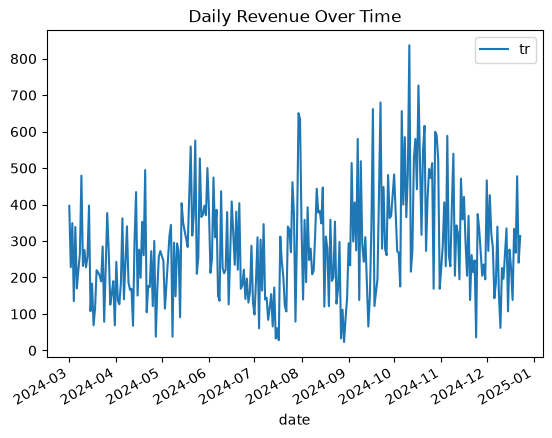

In [ ]:
#14.

data_data.plot.line(
    x = "date",
    y = "tr",
    title = "Daily Revenue Over Time",
)

In [36]:
#15.

def summarize_data(df, column):
    summary = {
        "mean": df[column].mean(),
        "median": df[column].median(),
        "std_dev": df[column].std(),
        "min": df[column].min(),
        "max": df[column].max()
    }
    return summary

summarize_data(data_data, "tr")

{'mean': np.float64(284.510544217687),
 'median': np.float64(271.53999999999996),
 'std_dev': np.float64(145.42938476789698),
 'min': np.float64(23.02),
 'max': np.float64(836.6599999999999)}

##### 3. Forecasting Analysis

    - As a forecasting analysis a few operations will be tested on the data set, with the aim to collect data for a theoretical "executive summary"

    1. What is the main variable ? Does it have seasonality or trend? (2 solutions)
    2. Which variable could be selected as the primary focus to describe the main variable?
    3. Based on (1.) and (2.) run a regression to get relationship. What properties needs to be considered, is it going to be a static or predictive regression?
    4. Split data, use train set for regressio nestimation, estimate residiuals as well as its test set performance
    5. Forecast for December month
    6. Estimate ARIMA, evaluate model perofrmance
    7. Forecast with ARIMA
    8. Compare models, is it good to compare?
    9. Estimate forecast combination with equal and GR weights
    10. Give an answer which is the best forecast
            - regression
            - ARIMA
            - model combination